# Demo for Cross Response Analysis

This notebook demonstrates how to investigate the linear response on a fixed batch of test data. 

In [1]:
import os

import pandas as pd
import pytorch_lightning as pl
import seaborn as sn
import torch
import torchvision
from IPython.display import display
from pytorch_lightning.callbacks import LearningRateMonitor
from pytorch_lightning.loggers import CSVLogger
from torch.utils.data import DataLoader, random_split
from torchvision.datasets import CIFAR10
import torch.utils.data as data

from torchvision.models import VisionTransformer

from perspic.analyzer import analyzer
from perspic import MultiEpochsDataLoader
from examples.models import BatchNormMLP, ClassificationModule, WideResNet
from examples.models.utils import print_model_info

from pytorch_lightning.profilers import SimpleProfiler
from pytorch_lightning.utilities.combined_loader import CombinedLoader


import matplotlib.pyplot as plt

pl.seed_everything(7)

PATH_DATASETS = os.environ.get("PATH_DATASETS", ".")
BATCH_SIZE = 256 if torch.cuda.is_available() else 64
NUM_WORKERS = int(os.cpu_count() / 2)

Seed set to 7


In [2]:
# CIFAR10 mean and std
stats = ((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010))
train_transform = torchvision.transforms.Compose([
    torchvision.transforms.RandomCrop(32, padding=4),
    torchvision.transforms.RandomHorizontalFlip(),
    torchvision.transforms.ToTensor(),
    torchvision.transforms.Normalize(*stats),
])
test_transform = torchvision.transforms.Compose([
    torchvision.transforms.ToTensor(),
    torchvision.transforms.Normalize(*stats),
])

# Load datasets
# We instantiate the dataset twice to apply different transforms to train and val splits
train_dataset_full = CIFAR10(PATH_DATASETS, train=True, download=True, transform=train_transform)
val_dataset_full = CIFAR10(PATH_DATASETS, train=True, download=True, transform=test_transform)
test_set = CIFAR10(PATH_DATASETS, train=False, download=True, transform=test_transform)
# Create measurement set consisting of a subset of test set containing 500 random samples
test_indices = torch.randperm(len(test_set))[:500]
measurement_set = torch.utils.data.Subset(test_set, test_indices)

# Split train/val (45k/5k)
# We use the same seed to ensure the split indices are identical for both dataset instances
generator = torch.Generator().manual_seed(42)
train_set, _ = random_split(train_dataset_full, [45000, 5000], generator=generator)
_, val_set = random_split(val_dataset_full, [45000, 5000], generator=generator)

# DataLoaders
# We set drop_last=True to avoid spikes in gradient norms caused by smaller last batches
train_dataloader = DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, drop_last=True)
val_dataloader = DataLoader(val_set, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, drop_last=True)
test_dataloader = DataLoader(test_set, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, drop_last=True)

# Measurement DataLoader with MultiEpochsDataLoader to cycle through the small measurement set
measurement_dataloader = MultiEpochsDataLoader(
    measurement_set,
    batch_size=500,
    shuffle=False,
    drop_last=True,
    num_workers=NUM_WORKERS,
)


loaders = {"train": train_dataloader, "measure": measurement_dataloader}
combined_loader = CombinedLoader(loaders, mode="max_size_cycle")

## Model Instrumentation

Here is the core of `perspic`. Instead of just instantiating your `LightningModule`, you wrap it with the `analyzer` function.
This wrapper injects the necessary hooks to calculate sample-wise metrics (using `functorch` in this example) and logs them automatically.

In [3]:
# --- Helper Functions for Plotting ---

# Analysis metrics use "analysis_step" to avoid collision with Lightning's "step" column
ANALYSIS_METRICS = {"chi_net", "chi_loss", "loss", "grad_norm_squared",
                    "cross_loss", "cross_grad_dot_product",
                    "batch_size", "chi_coup", "window_id", "window_center",
                    "cross_chi_net", "cross_chi_loss", "cross_chi_coup"}

def plot_metric(ax, data, column, label, color, alpha=0.35, ema_span=50, negate=False):
    """
    Plots raw data with transparency and an Exponential Moving Average (EMA) overlay.
    
    Args:
        ax: Matplotlib axes object.
        data: DataFrame containing the metrics.
        column: Name of the column to plot.
        label: Label for the legend.
        color: Color of the plot.
        alpha: Transparency for the raw data.
        ema_span: Span for the EMA calculation.
        negate: If True, plots the negative of the values.
    """
    # Use "analysis_step" for perspic metrics, "step" for Lightning metrics
    step_col = "analysis_step" if column in ANALYSIS_METRICS else "step"
    
    # Fall back to "step" if analysis_step doesn't exist (backward compatibility)
    if step_col == "analysis_step" and step_col not in data.columns:
        step_col = "step"
    
    # Filter and sort data
    subset = data[[column, step_col]].dropna().sort_values(step_col)
    
    # Handle log(0) issue by shifting steps if they start at 0
    steps = subset[step_col]
    if len(steps) > 0 and steps.min() == 0:
        steps = steps + 1
        
    values = subset[column].values
    if negate:
        values = -values
        
    series = pd.Series(values, index=steps)
    
    # Plotting Logic
    if len(series) > 50: 
        # High-frequency data: Plot Raw (noisy) + EMA (smooth)
        ax.plot(series.index, series.values, color=color, alpha=alpha, linewidth=1, label=f"{label} (Raw)")
        ema = series.ewm(span=ema_span).mean()
        ax.plot(series.index, ema.values, color=color, label=f"{label} (EMA)", linewidth=2)
    else:
        # Low-frequency data (e.g. validation): Plot markers
        ax.plot(series.index, series.values, color=color, label=label, marker='o', linestyle='--', linewidth=2)

def configure_axis(ax, title, ylabel, xlabel="Step (log scale)", xscale="log", yscale="linear"):
    """Configures the appearance of a subplot axis."""
    ax.set_title(title)
    ax.set_ylabel(ylabel)
    ax.set_xlabel(xlabel)
    ax.set_xscale(xscale)
    ax.set_yscale(yscale)
    ax.grid(True, alpha=0.3, which="both")
    # Only add legend if there are labeled artists
    if ax.get_legend_handles_labels()[0]:
        ax.legend(loc="best")


def plot_training_metrics(metrics, title=None, figsize=(15, 18), ema_span=50):
    """
    Plot training metrics from a CSV file or DataFrame.
    
    Args:
        metrics: Either a path to a CSV file (str) or a pandas DataFrame containing the metrics.
        title: Optional title for the figure (e.g., model name).
        figsize: Figure size as a tuple (width, height).
        ema_span: Span for the Exponential Moving Average calculation.
    
    Returns:
        fig, axes: The matplotlib figure and axes objects.
    """
    # Load data if path is provided
    if isinstance(metrics, str):
        metrics = pd.read_csv(metrics)
    
    # Display first few rows to show what's being tracked
    print("Tracked Metrics:")
    display(metrics.dropna(axis=1, how="all").head())

    # --- Plotting Configuration ---
    fig, axes = plt.subplots(3, 2, figsize=figsize)
    axes = axes.flatten()
    
    if title:
        fig.suptitle(title, fontsize=16, fontweight='bold', y=1.02)

    # --- Generate Subplots ---

    # Subplot 1: Loss & Accuracy
    ax_loss = axes[0]
    if "train_loss" in metrics.columns:
        plot_metric(ax_loss, metrics, "train_loss", "Train Loss", "blue", ema_span=ema_span)
    if "val_loss" in metrics.columns:
        plot_metric(ax_loss, metrics, "val_loss", "Val Loss", "cyan", ema_span=ema_span)
    if "cross_loss" in metrics.columns:
        plot_metric(ax_loss, metrics, "cross_loss", "Cross Loss", "coral", ema_span=ema_span)

    configure_axis(ax_loss, "Loss & Accuracy", "Loss")

    # Add Accuracy on secondary axis
    if "train_acc" in metrics.columns or "val_acc" in metrics.columns:
        ax_acc = ax_loss.twinx()
        if "train_acc" in metrics.columns:
            plot_metric(ax_acc, metrics, "train_acc", "Train Acc", "red", ema_span=ema_span)
        if "val_acc" in metrics.columns:
            plot_metric(ax_acc, metrics, "val_acc", "Val Acc", "orange", ema_span=ema_span)
        ax_acc.set_ylabel("Accuracy")
        # Combine legends from both axes
        lines_1, labels_1 = ax_loss.get_legend_handles_labels()
        lines_2, labels_2 = ax_acc.get_legend_handles_labels()
        ax_loss.legend(lines_1 + lines_2, labels_1 + labels_2, loc="upper left")


    # Subplot 2: Gradient Norm (Loss) - chi_loss
    ax_grad_loss = axes[1]
    if "chi_loss" in metrics.columns:
        plot_metric(ax_grad_loss, metrics, "chi_loss", "χ_loss (Self)", "purple", ema_span=ema_span)
    if "cross_chi_loss" in metrics.columns:
        plot_metric(ax_grad_loss, metrics, "cross_chi_loss", "χ_loss (Cross)", "violet", ema_span=ema_span)
    configure_axis(ax_grad_loss, "Gradient Norm (Loss)", "χ_loss")


    # Subplot 3: Gradient Norm (Network) - chi_net
    ax_grad_net = axes[2]
    if "chi_net" in metrics.columns:
        plot_metric(ax_grad_net, metrics, "chi_net", "χ_net (Self)", "green", ema_span=ema_span)
    if "cross_chi_net" in metrics.columns:
        plot_metric(ax_grad_net, metrics, "cross_chi_net", "χ_net (Cross)", "lime", ema_span=ema_span)
    configure_axis(ax_grad_net, "Gradient Norm (Network)", "χ_net", yscale="log")


    # Subplot 4: Coupling Coefficient
    ax_chi_coup = axes[3]
    if "chi_coup" in metrics.columns:
        plot_metric(ax_chi_coup, metrics, "chi_coup", "χ_coup (Self)", "orange", ema_span=ema_span)
    if "cross_chi_coup" in metrics.columns:
        plot_metric(ax_chi_coup, metrics, "cross_chi_coup", "χ_coup (Cross)", "magenta", ema_span=ema_span)
    configure_axis(ax_chi_coup, "Coupling Coefficient", "χ_coup", yscale="log")


    # Subplot 5: Gradient Norm Squared (||∇L||²)
    ax_grad_norm = axes[4]
    if "grad_norm_squared" in metrics.columns:
        plot_metric(ax_grad_norm, metrics, "grad_norm_squared", "||∇L||² (Self)", "brown", negate=False, ema_span=ema_span)
    if "cross_grad_dot_product" in metrics.columns:
        plot_metric(ax_grad_norm, metrics, "cross_grad_dot_product", "∇L₁ᵀ∇L₂ (Cross)", "teal", ema_span=ema_span)
    configure_axis(ax_grad_norm, "Gradient Norm Squared / Dot Product", "Value", yscale="log")


    # Subplot 6: Removed (Empty)
    ax_cross = axes[5]
    ax_cross.axis('off')

    plt.tight_layout()
    plt.show()
    
    return fig, axes

In [4]:
# Wrap the model with the analyzer
# This adds the capability to track additional metrics (like gradients) during training
resnet_model = analyzer(
    lightning_module=ClassificationModule, 
    sample_wise_engine="opacus",
    model=WideResNet(10, 10, dropRate=0.0),
    lr=0.1, 
    cross_response=True,
)

# Define the Trainer
trainer = pl.Trainer(
    max_epochs=10,
    accelerator="auto",
    devices=1,
    logger=CSVLogger(save_dir="logs/"),
    callbacks=[LearningRateMonitor(logging_interval="step")],
    log_every_n_steps=1,
)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


In [5]:
# Train and test the model

trainer.fit(resnet_model, train_dataloaders=combined_loader, val_dataloaders=val_dataloader)
trainer.test(resnet_model, dataloaders=test_dataloader)

You are using a CUDA device ('NVIDIA GeForce RTX 3090 Ti') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name  | Type       | Params | Mode 
---------------------------------------------
0 | model | WideResNet | 77.9 K | train
---------------------------------------------
77.9 K    Trainable params
0         Non-trainable params
77.9 K    Total params
0.311     Total estimated model params size (MB)
34        Modules in train mode
0         Modules in eval mode


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=10` reached.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Testing: |          | 0/? [00:00<?, ?it/s]

────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
       Test metric             DataLoader 0
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
        test_acc            0.6561498641967773
        test_loss           1.0107508897781372
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────


[{'test_loss': 1.0107508897781372, 'test_acc': 0.6561498641967773}]

Tracked Metrics:


,analysis_step,batch_size,chi_coup,chi_loss,chi_net,cross_batch_size,cross_chi_coup,cross_chi_loss,cross_chi_net,cross_grad_dot_product,...,grad_norm_squared,loss,lr-Adam,step,test_acc,test_loss,train_acc,train_loss,val_acc,val_loss
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,0.1,0,NaN,NaN,NaN,NaN,NaN,NaN
1,0.0,256.0,0.000773,0.899989,506.483948,500.0,0.000691,0.901176,546.685547,0.340598,...,0.352274,2.299370,NaN,0,NaN,NaN,0.109375,2.299370,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,0.1,1,NaN,NaN,NaN,NaN,NaN,NaN
3,1.0,256.0,0.014247,1.010283,3979.744141,500.0,0.014007,1.019541,4286.231934,61.211189,...,57.281319,3.249753,NaN,1,NaN,NaN,0.136719,3.249753,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,0.1,2,NaN,NaN,NaN,NaN,NaN,NaN


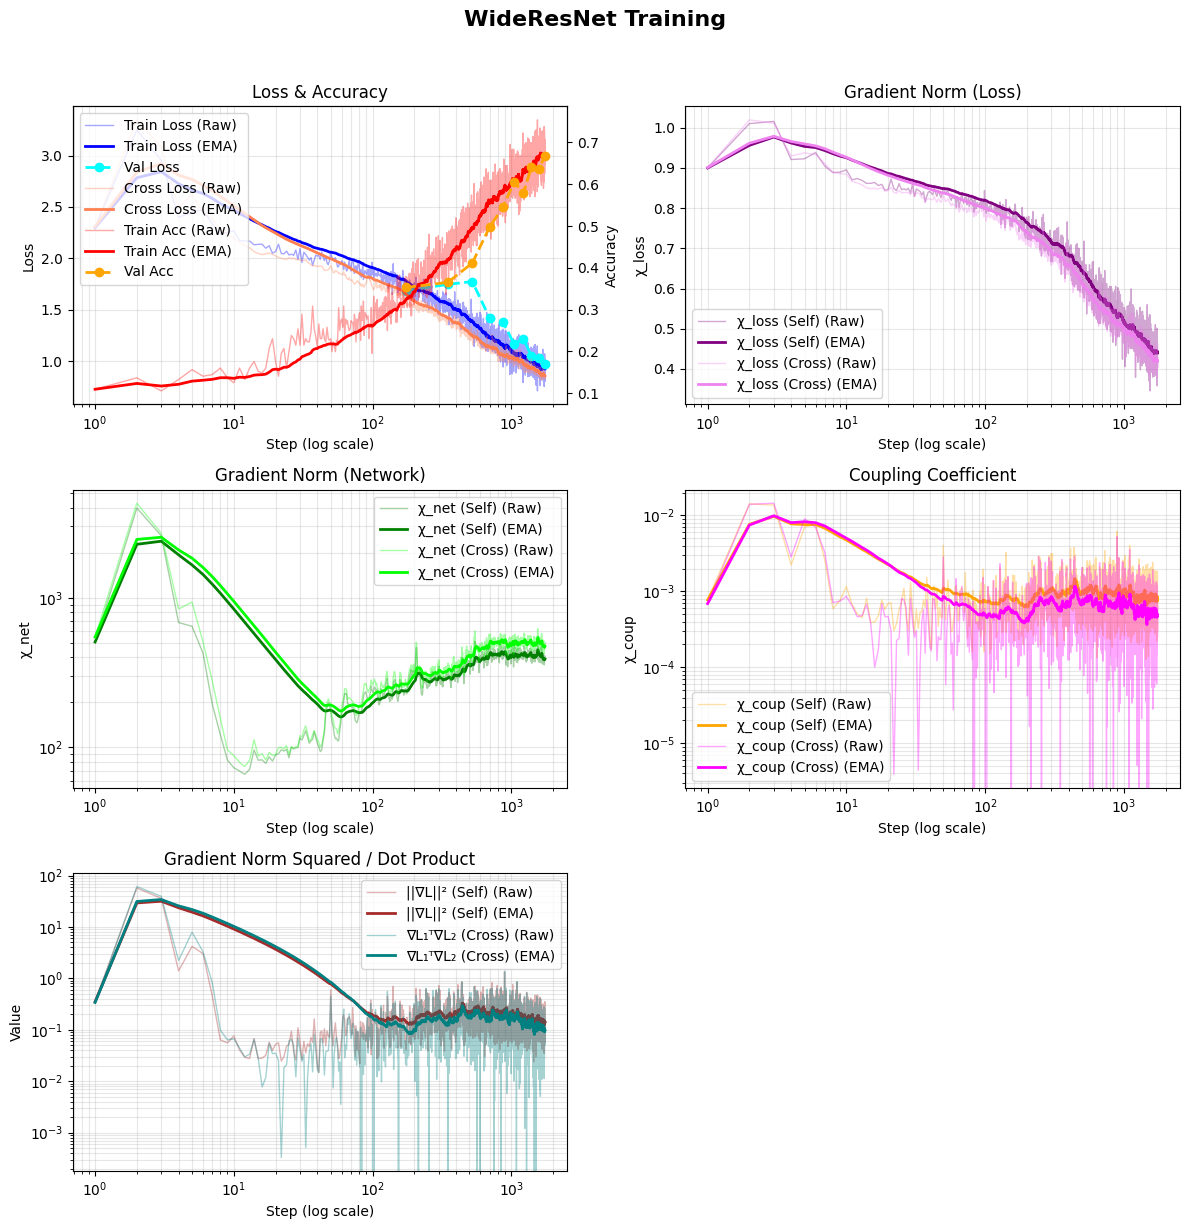

(<Figure size 1200x1200 with 7 Axes>,
 array([<Axes: title={'center': 'Loss & Accuracy'}, xlabel='Step (log scale)', ylabel='Loss'>,
        <Axes: title={'center': 'Gradient Norm (Loss)'}, xlabel='Step (log scale)', ylabel='χ_loss'>,
        <Axes: title={'center': 'Gradient Norm (Network)'}, xlabel='Step (log scale)', ylabel='χ_net'>,
        <Axes: title={'center': 'Coupling Coefficient'}, xlabel='Step (log scale)', ylabel='χ_coup'>,
        <Axes: title={'center': 'Gradient Norm Squared / Dot Product'}, xlabel='Step (log scale)', ylabel='Value'>,
        <Axes: >], dtype=object))

In [6]:
# Example usage with current trainer
plot_training_metrics(f"{trainer.logger.log_dir}/metrics.csv", title="WideResNet Training", figsize=(12, 12))

In [7]:
# Inititalize models


# Even smaller / "tiny" variant
model_vit_small = VisionTransformer(
    image_size=32,
    patch_size=8,
    num_layers=2,
    num_heads=4,
    hidden_dim=128,
    mlp_dim=256,
    num_classes=10,
)
print_model_info(model_vit_small, verbose=False)

# vit_model = ClassificationModule(model_vit_medium, lr=0.005,)
vit_model = analyzer(
    lightning_module=ClassificationModule, 
    # sample_wise_engine="functorch", 
    sample_wise_engine="opacus",
    opacus_strict=True,
    model=model_vit_small,
    lr=0.005,
    cross_response=True,
)
trainer = pl.Trainer(
    max_epochs=5,
    # max_steps=2,
    accelerator="auto",
    devices=1,
    logger=CSVLogger(save_dir="logs/"),
    callbacks=[LearningRateMonitor(logging_interval="step")],
    log_every_n_steps=1,
    # profiler="advanced",
)

trainer.fit(vit_model, train_dataloaders=combined_loader, val_dataloaders=val_dataloader)
trainer.test(vit_model, dataloaders=test_dataloader)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name  | Type              | Params | Mode 
----------------------------------------------------
0 | model | VisionTransformer | 293 K  | train
----------------------------------------------------
293 K     Trainable params
0         Non-trainable params
293 K     Total params
1.174     Total estimated model params size (MB)
32        Modules in train mode
0         Modules in eval mode


Model: VisionTransformer
Number of trainable parameters: 293,514
--------------------------------------------------


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=5` reached.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Testing: |          | 0/? [00:00<?, ?it/s]

────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
       Test metric             DataLoader 0
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
        test_acc            0.35146233439445496
        test_loss           1.7459534406661987
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────


[{'test_loss': 1.7459534406661987, 'test_acc': 0.35146233439445496}]

Tracked Metrics:


,analysis_step,batch_size,chi_coup,chi_loss,chi_net,cross_batch_size,cross_chi_coup,cross_chi_loss,cross_chi_net,cross_grad_dot_product,...,grad_norm_squared,loss,lr-Adam,step,test_acc,test_loss,train_acc,train_loss,val_acc,val_loss
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,0.005,0,NaN,NaN,NaN,NaN,NaN,NaN
1,0.0,256.0,0.000868,0.900000,1289.998291,500.0,0.000787,0.900000,1289.998413,0.913684,...,1.008268,2.302585,NaN,0,NaN,NaN,0.078125,2.302585,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,0.005,1,NaN,NaN,NaN,NaN,NaN,NaN
3,1.0,256.0,0.000787,0.885549,1549.413940,500.0,0.000387,0.882569,1552.200928,0.530547,...,1.079473,2.233878,NaN,1,NaN,NaN,0.207031,2.233878,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,0.005,2,NaN,NaN,NaN,NaN,NaN,NaN


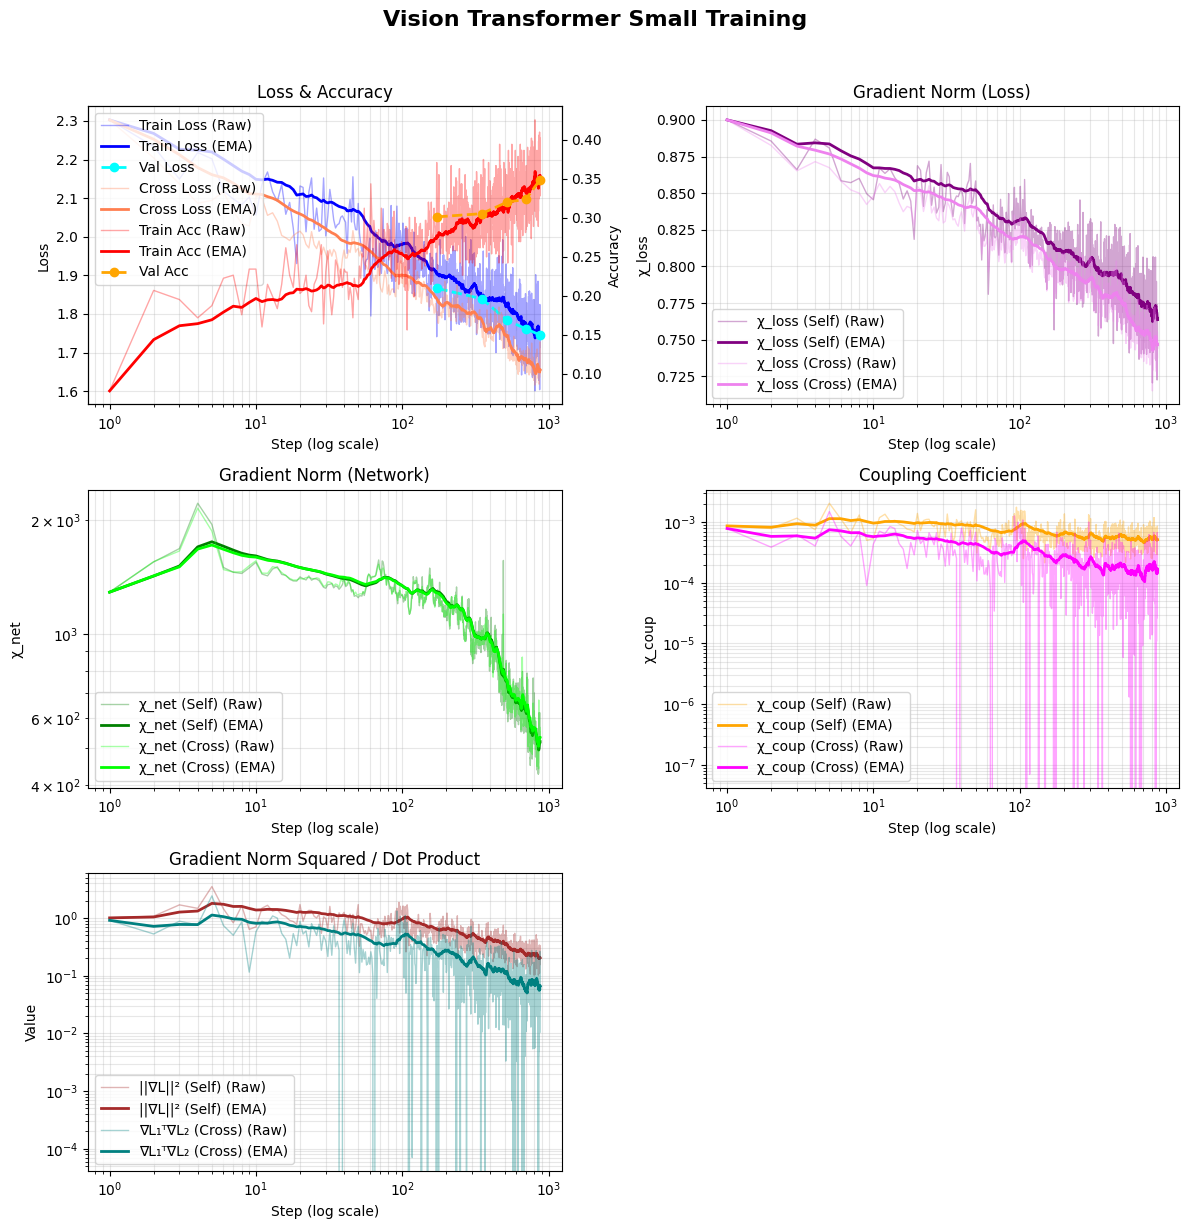

(<Figure size 1200x1200 with 7 Axes>,
 array([<Axes: title={'center': 'Loss & Accuracy'}, xlabel='Step (log scale)', ylabel='Loss'>,
        <Axes: title={'center': 'Gradient Norm (Loss)'}, xlabel='Step (log scale)', ylabel='χ_loss'>,
        <Axes: title={'center': 'Gradient Norm (Network)'}, xlabel='Step (log scale)', ylabel='χ_net'>,
        <Axes: title={'center': 'Coupling Coefficient'}, xlabel='Step (log scale)', ylabel='χ_coup'>,
        <Axes: title={'center': 'Gradient Norm Squared / Dot Product'}, xlabel='Step (log scale)', ylabel='Value'>,
        <Axes: >], dtype=object))

In [8]:
# Example usage with current trainer
plot_training_metrics(f"{trainer.logger.log_dir}/metrics.csv", title="Vision Transformer Small Training", figsize=(12, 12))